# Week 6 — Wave Kinematics: Velocities, Orbits, Pressure

**OE 754 / 854 — Ocean Waves & Tides**

We have the Airy solution. Now we can ask what a coastal or offshore engineer needs to know:

- What are the fluid velocities underneath a wave?
- What paths do individual parcels trace out?
- What is the pressure a meter below the surface? On the seabed?

This week's lecture gave us the formulas. Here we implement them and run the three-case exercise from the notes (deep, intermediate, shallow). The results reproduce the asymptotic behavior in the summary table.

### Key formulas (from the lecture)

Given $\eta = (H/2)\cos(kx - \omega t)$:

$$u = \frac{H\omega}{2}\,\frac{\cosh k(h+z)}{\sinh kh}\cos(kx-\omega t),
  \qquad
  w = \frac{H\omega}{2}\,\frac{\sinh k(h+z)}{\sinh kh}\sin(kx-\omega t).$$

Particle orbits are ellipses with semi-axes

$$A(z) = \frac{H}{2}\frac{\cosh k(h+z)}{\sinh kh}, \qquad
  B(z) = \frac{H}{2}\frac{\sinh k(h+z)}{\sinh kh}.$$

Dynamic pressure:

$$p_{\text{dyn}} = \rho g\, \eta\, K_p(z), \qquad
  K_p(z) = \frac{\cosh k(h+z)}{\cosh kh}.$$

### The three cases

| Case         | $H$   | $T$     | $h$    | Expected behavior                                       |
|--------------|-------|---------|--------|---------------------------------------------------------|
| Deep         | 2 m   | 10 s    | 80 m   | Nearly-circular orbits, exponential decay with depth    |
| Intermediate | 1 m   | 6 s     | 5 m    | Visibly elliptical, $|u|$ finite at seabed              |
| Shallow      | 0.5 m | 20 s    | 3 m    | Very flat orbits, $|u|$ nearly uniform with depth       |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import figure_style as fs

g = 9.81
rho = 1025.0  # kg/m^3, seawater

## 1. A small wave class

Let's build the three cases once and query them, so we don't retype $(H, T, h)$ everywhere. The class solves the dispersion relation and returns the kinematic fields.

In [2]:
def solve_k(omega, h, tol=1e-12):
    r'''Newton's method on omega^2 = g k tanh(kh), starting at the deep-water k.'''
    k = omega**2 / g
    for _ in range(50):
        tkh = np.tanh(k * h)
        f = omega**2 - g * k * tkh
        fp = -g * tkh - g * h * k * (1 - tkh**2)
        dk = f / fp
        k -= dk
        if abs(dk) < tol:
            break
    return k


class AiryWave:
    r'''A monochromatic Airy wave with height H, period T, depth h.'''
    def __init__(self, H, T, h):
        self.H = H
        self.T = T
        self.h = h
        self.omega = 2 * np.pi / T
        self.k = solve_k(self.omega, h)
        self.L = 2 * np.pi / self.k
        self.C = self.L / T
        self.kh = self.k * h
        self.n = 0.5 * (1 + 2 * self.kh / np.sinh(2 * self.kh))
        self.Cg = self.n * self.C

    def regime(self):
        if self.kh > np.pi:
            return 'deep'
        if self.kh < np.pi / 10:
            return 'shallow'
        return 'intermediate'

    def u(self, x, z, t):
        r'''Horizontal velocity.'''
        a = self.H / 2 * self.omega
        return a * np.cosh(self.k * (self.h + z)) / np.sinh(self.kh) \
                 * np.cos(self.k * x - self.omega * t)

    def w(self, x, z, t):
        r'''Vertical velocity.'''
        a = self.H / 2 * self.omega
        return a * np.sinh(self.k * (self.h + z)) / np.sinh(self.kh) \
                 * np.sin(self.k * x - self.omega * t)

    def orbit_semiaxes(self, z):
        r'''(A, B) = (horizontal, vertical) semi-axes of the orbit at depth z.'''
        A = (self.H / 2) * np.cosh(self.k * (self.h + z)) / np.sinh(self.kh)
        B = (self.H / 2) * np.sinh(self.k * (self.h + z)) / np.sinh(self.kh)
        return A, B

    def Kp(self, z):
        r'''Pressure response factor.'''
        return np.cosh(self.k * (self.h + z)) / np.cosh(self.kh)

    def summary(self):
        print(f'H = {self.H} m, T = {self.T} s, h = {self.h} m')
        print(f'  L  = {self.L:7.3f} m    k    = {self.k:.5f} rad/m')
        print(f'  kh = {self.kh:7.3f}      regime = {self.regime()}')
        print(f'  C  = {self.C:7.3f} m/s  C_g  = {self.Cg:.3f} m/s    n = {self.n:.3f}')


# Three cases from the lecture exercise
deep = AiryWave(H=2.0,  T=10.0, h=80.0)
intm = AiryWave(H=1.0,  T=6.0,  h=5.0)
shlw = AiryWave(H=0.5,  T=20.0, h=3.0)

for w in (deep, intm, shlw):
    w.summary()
    print()

H = 2.0 m, T = 10.0 s, h = 80.0 m
  L  = 155.643 m    k    = 0.04037 rad/m
  kh =   3.230      regime = deep
  C  =  15.564 m/s  C_g  = 7.940 m/s    n = 0.510

H = 1.0 m, T = 6.0 s, h = 5.0 m
  L  =  38.090 m    k    = 0.16496 rad/m
  kh =   0.825      regime = intermediate
  C  =   6.348 m/s  C_g  = 5.263 m/s    n = 0.829

H = 0.5 m, T = 20.0 s, h = 3.0 m
  L  = 107.953 m    k    = 0.05820 rad/m
  kh =   0.175      regime = shallow
  C  =   5.398 m/s  C_g  = 5.344 m/s    n = 0.990



The $kh$ values confirm the regime labels:

- **Deep**: $kh \approx 3.23$, just past $\pi \approx 3.14$. $\tanh kh = 0.997$, so the deep-water formulas work well here.
- **Intermediate**: $kh \approx 0.83$, between $\pi/10 \approx 0.31$ and $\pi$ (far from both cutoffs). This case needs the full dispersion relation.
- **Shallow**: $kh \approx 0.18$, well below the $\pi/10$ cutoff. $n = 0.99$, so $C_g$ is within 1% of $C$. A 20-second wave in 3 m of water is a shallow-water wave.

## 2. Velocity amplitudes vs. depth

The horizontal and vertical velocity amplitudes are

$$|u|_{\max}(z) = \frac{H\omega}{2}\,\frac{\cosh k(h+z)}{\sinh kh}, \qquad
  |w|_{\max}(z) = \frac{H\omega}{2}\,\frac{\sinh k(h+z)}{\sinh kh}.$$

Both are functions of $z$ only. Plot them against depth for all three cases.

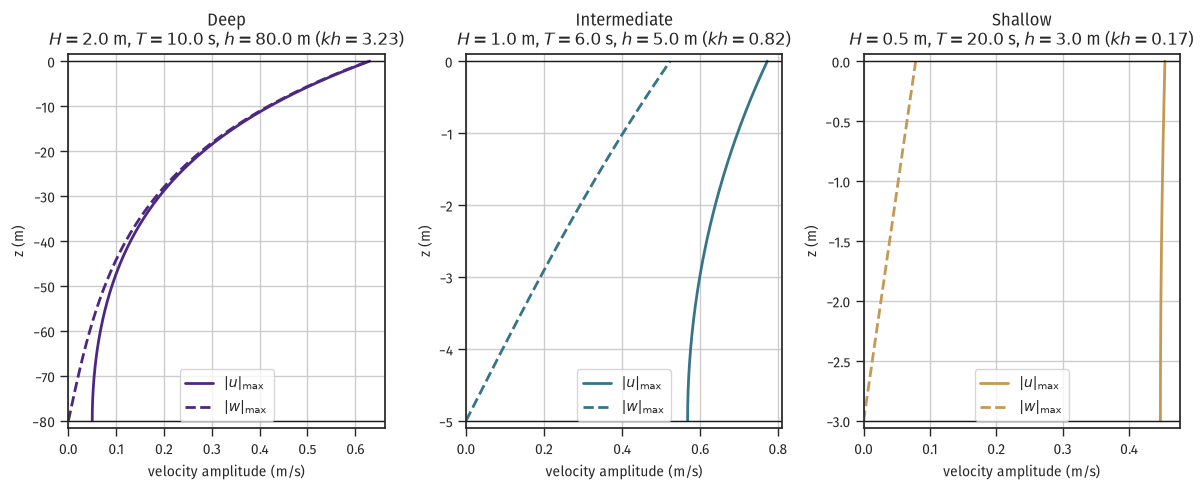

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=False)

cases = [('Deep',         deep, fs.color_list[0]),
         ('Intermediate', intm, fs.color_list[1]),
         ('Shallow',      shlw, fs.color_list[3])]

for ax, (label, wv, color) in zip(axes, cases):
    z = np.linspace(-wv.h, 0.0, 200)
    u_amp = (wv.H / 2 * wv.omega) * np.cosh(wv.k * (wv.h + z)) / np.sinh(wv.kh)
    w_amp = (wv.H / 2 * wv.omega) * np.sinh(wv.k * (wv.h + z)) / np.sinh(wv.kh)
    ax.plot(u_amp, z, '-',  label=r'$|u|_{\max}$', lw=2, color=color)
    ax.plot(w_amp, z, '--', label=r'$|w|_{\max}$', lw=2, color=color)
    ax.axhline(0, color='k', lw=1)
    ax.axhline(-wv.h, color='k', lw=1)
    ax.set_xlim(left=0)
    ax.set_ylim(-wv.h * 1.02, 0.02 * wv.h)
    ax.set_xlabel('velocity amplitude (m/s)')
    ax.set_ylabel('z (m)')
    ax.set_title(f'{label}\n$H={wv.H}$ m, $T={wv.T}$ s, $h={wv.h}$ m ($kh={wv.kh:.2f}$)',
                 fontsize=12)
    ax.legend(loc='lower center')

plt.tight_layout()
plt.show()

Reading the three panels:

- In **deep water**, both $|u|$ and $|w|$ decay exponentially with depth. Both are near zero well before $z = -h$. The wave motion is confined to a surface layer about $L/2$ thick.
- In **intermediate water**, $|u|$ decays more gently and is not zero at the seabed. $|w|$ always goes to zero at $z = -h$ (the $\sinh$ factor). That is the bottom boundary condition: no flow through the bed.
- In **shallow water**, $|u|$ is nearly uniform with depth. The whole column moves back and forth together. In the shallow-water limit the horizontal velocity is depth-independent. $|w|$ is small everywhere and still zero at the bed.

## 3. Particle orbits

A parcel with undisturbed position $(x_0, z_0)$ traces the ellipse

$$x(t) - x_0 = -A(z_0)\sin(kx_0 - \omega t), \qquad
  z(t) - z_0 = B(z_0)\cos(kx_0 - \omega t),$$

with semi-axes $A(z_0)$ horizontal, $B(z_0)$ vertical. Let's look at the orbital motion ellipses at several depths in each regime.

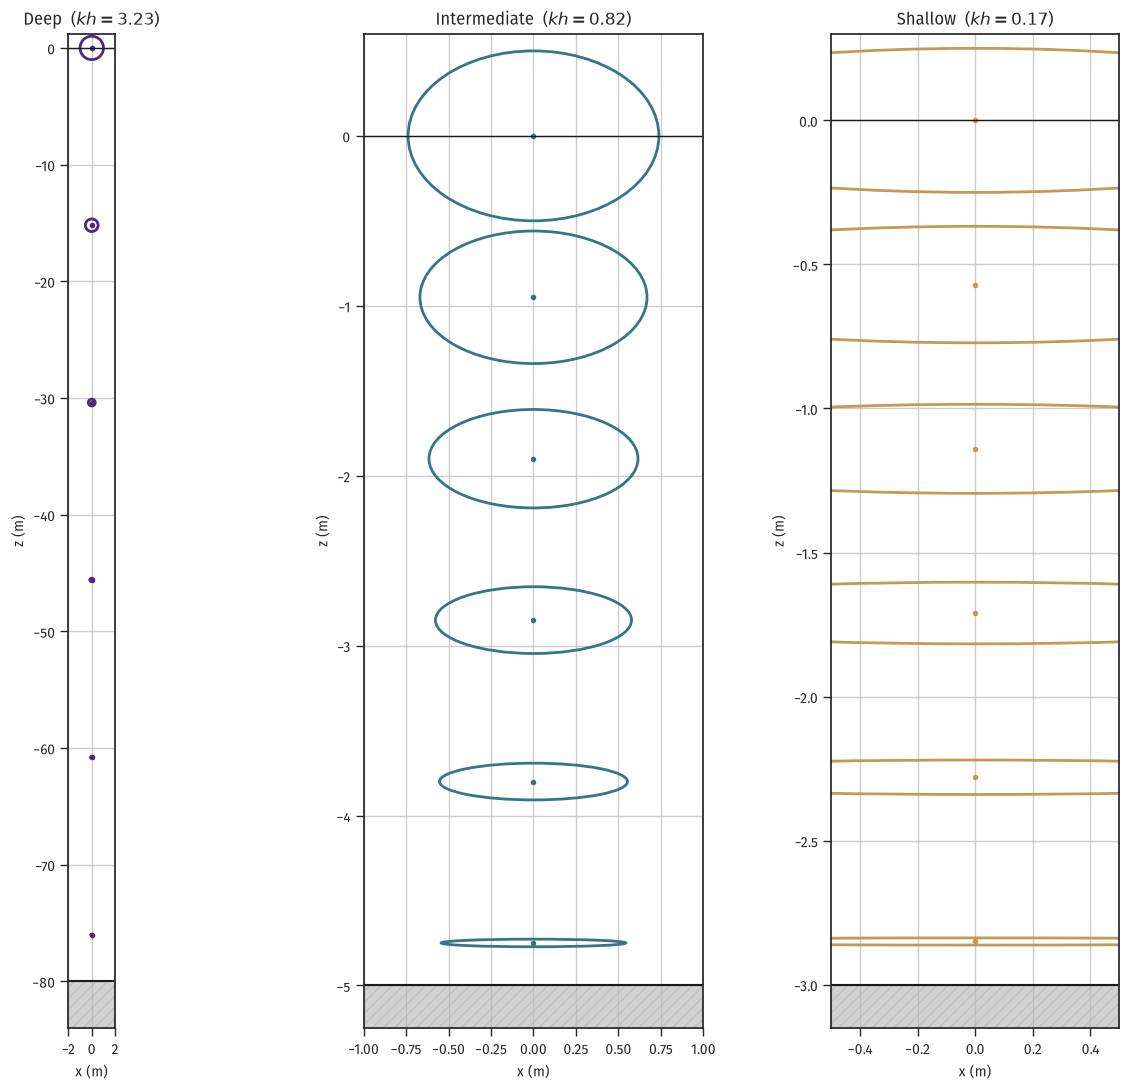

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 11))

for ax, (label, wv, color) in zip(axes, cases):
    # Six depths, surface down to just above the bed
    depths = np.linspace(0, -wv.h * 0.95, 6)
    for z in depths:
        A, B = wv.orbit_semiaxes(z)
        ellipse = Ellipse(xy=(0, z), width=2 * A, height=2 * B,
                          fill=False, edgecolor=color, lw=2)
        ax.add_patch(ellipse)
        ax.plot(0, z, 'o', color=color, ms=3)
    ax.axhline(0, color='k', lw=1)
    ax.axhline(-wv.h, color='k', lw=1.5)
    ax.fill_between([-wv.H, wv.H], -wv.h * 1.1, -wv.h,
                    color='0.7', alpha=0.6, hatch='///')
    ax.set_xlim(-wv.H, wv.H)
    ax.set_ylim(-wv.h * 1.05, wv.H * 0.6)
    ax.set_aspect('equal')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    ax.set_title(f'{label}  ($kh={wv.kh:.2f}$)', fontsize=12)

plt.tight_layout()
plt.show()

The three cases from the lecture:

- **Deep:** orbits are circles near the surface and shrink exponentially with depth. The bottom orbits are too small to see. By $z \approx -L/2$ the motion is down to about 4% of its surface value.
- **Intermediate:** orbits are visibly elliptical. Both axes are finite most of the way down. At $z = -h$ the vertical axis $B$ goes to zero and the horizontal axis $A$ stays finite.
- **Shallow:** orbits are long, flat ellipses. Horizontal motion is much larger than vertical. The near-bed orbit is nearly a horizontal line.

(The semi-axes are not drawn to the same scale across the three subplots. Compare shapes only.)

### Check: the deep-water circle

In the deep-water limit, $A(z) \to (H/2)e^{kz}$ and $B(z) \to (H/2)e^{kz}$. Equal axes, so circular orbits. Confirm for the deep case:

In [7]:
print(f"Deep case (kh = {deep.kh:.2f}):")
print(f"  At z = 0:         A = {deep.orbit_semiaxes(0)[0]:.4f} m, "
      f"B = {deep.orbit_semiaxes(0)[1]:.4f} m, "
      f"A/B = {deep.orbit_semiaxes(0)[0]/deep.orbit_semiaxes(0)[1]:.4f}")
print(f"  At z = -10 m:     A = {deep.orbit_semiaxes(-10)[0]:.4f} m, "
      f"B = {deep.orbit_semiaxes(-10)[1]:.4f} m, "
      f"A/B = {deep.orbit_semiaxes(-10)[0]/deep.orbit_semiaxes(-10)[1]:.4f}")

# Deep-water limit: A = B = (H/2) exp(kz)
z_check = -10
A_theory = (deep.H / 2) * np.exp(deep.k * z_check)
print(f"  Deep-water theory:  A = B = (H/2) exp(kz) = {A_theory:.4f} m")

Deep case (kh = 3.23):
  At z = 0:         A = 1.0031 m, B = 1.0000 m, A/B = 1.0031
  At z = -10 m:     A = 0.6712 m, B = 0.6665 m, A/B = 1.0070
  Deep-water theory:  A = B = (H/2) exp(kz) = 0.6678 m


$A$ and $B$ agree to about two decimal places at the surface ($A/B = 1.003$). The agreement degrades slowly with depth ($A/B = 1.007$ at $z = -10$ m), since $A/B = \coth k(h+z)$. Both stay within 1% of the deep-water value.

## 4. Pressure: $K_p(z)$ and the bottom-pressure problem

The dynamic pressure is $p_{\text{dyn}}(x,z,t) = \rho g\,\eta(x,t)\,K_p(z)$, with the pressure response factor

$$K_p(z) = \frac{\cosh k(h+z)}{\cosh kh}.$$

$K_p = 1$ at the surface (pressure and surface elevation in phase, amplitude $\rho g$) and decreases with depth. This is how you infer wave height from a bottom-pressure sensor: invert the formula for $\eta$. It works provided the decay is not too steep.

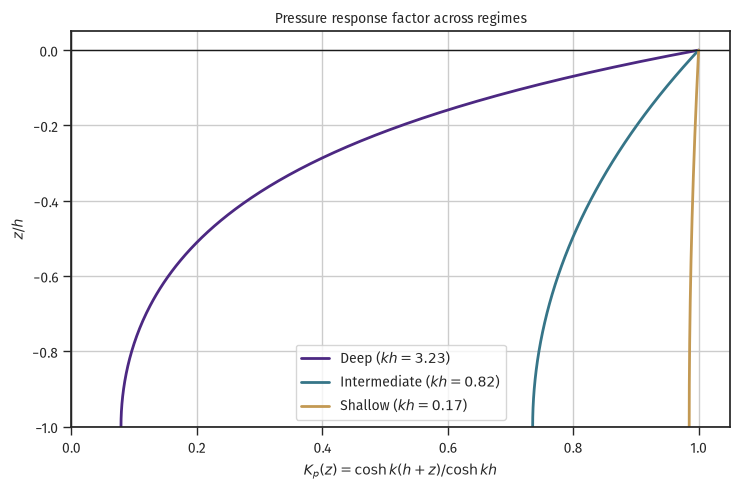

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5))

for label, wv, color in cases:
    z = np.linspace(-wv.h, 0, 200)
    Kp = wv.Kp(z)
    z_norm = z / wv.h
    ax.plot(Kp, z_norm, lw=2, color=color,
            label=f'{label} ($kh={wv.kh:.2f}$)')

ax.axvline(0, color='k', lw=1)
ax.axhline(0, color='k', lw=1)
ax.axhline(-1, color='k', lw=1)
ax.set_xlim(0, 1.05)
ax.set_ylim(-1.0, 0.05)
ax.set_xlabel(r'$K_p(z) = \cosh k(h+z) / \cosh kh$')
ax.set_ylabel(r'$z / h$')
ax.set_title(r'Pressure response factor across regimes')
ax.legend(loc='lower center')
plt.tight_layout()
plt.show()

The shallow curve is nearly vertical at $K_p = 1$: the pressure signal at the bed matches the surface (the hydrostatic limit). The deep curve drops to near zero at the bed: the water column filters the surface signal out. From the notes:

> If $kh$ is large, $\cosh kh$ is enormous, so the dynamic pressure reaching the seabed is tiny. Divide it back out and you amplify the noise along with the signal. A bottom-mounted pressure gauge is useless for open-ocean swell. Such gauges are deployed in shallow coastal water only.

Numbers:

In [9]:
print('Bottom K_p values:')
for label, wv, _ in cases:
    Kp_bed = wv.Kp(-wv.h)
    print(f'  {label:>14s}: K_p(-h) = {Kp_bed:.4f}  '
          f'({100*Kp_bed:.1f}% of the surface signal)')

Bottom K_p values:
            Deep: K_p(-h) = 0.0790  (7.9% of the surface signal)
    Intermediate: K_p(-h) = 0.7354  (73.5% of the surface signal)
         Shallow: K_p(-h) = 0.9849  (98.5% of the surface signal)


For the deep case, about 8 % of the surface signal reaches the seabed. For a 2-m surface wave, the dynamic pressure fluctuation at the bed is $\rho g \times 1\,\text{m} \times 0.08 \approx 800$ Pa (about 8 cm of equivalent water column). Detectable, but small. With a $\sim$50 Pa noise floor the SNR is thin.

## 5. Combined asymptotic summary

The table from the lecture, with our three cases filled in numerically:

In [10]:
def sh_deep_intm_expected(wv):
    kh = wv.kh
    r = wv.regime()
    return (
        wv.C,
        wv.Cg / wv.C,
        wv.orbit_semiaxes(0)[0],   # A(0), m
        wv.orbit_semiaxes(0)[1],   # B(0), m
        wv.Kp(-wv.h),              # K_p at the bed
    )

print(f"{'':>16s}{'Deep':>12s}{'Intermed.':>12s}{'Shallow':>12s}")
print('-' * 52)
labels = ['C (m/s)', 'C_g / C', 'A(0) (m)', 'B(0) (m)', 'K_p(bed)']
data = list(zip(*(sh_deep_intm_expected(w) for w in (deep, intm, shlw))))
for lab, row in zip(labels, data):
    print(f'{lab:>16s}{row[0]:>12.3f}{row[1]:>12.3f}{row[2]:>12.3f}')

                        Deep   Intermed.     Shallow
----------------------------------------------------
         C (m/s)      15.564       6.348       5.398
         C_g / C       0.510       0.829       0.990
        A(0) (m)       1.003       0.738       1.446
        B(0) (m)       1.000       0.500       0.250
        K_p(bed)       0.079       0.735       0.985


Reading the rows:

- $C_g/C$: from $\sim 1/2$ (deep) toward $1$ (shallow), as expected.
- $A(0)$: the surface horizontal semi-axis. In shallow water $A(0) \to H/(2kh)$, so the horizontal motion is large compared with $H/2$ as $kh \to 0$.
- $B(0)$: the surface vertical semi-axis. It is $H/2$ in every regime: the surface moves up and down by the amplitude.
- $K_p$ at the bed: from $\sim 1$ (shallow) down to $\sim 0.08$ (deep).

## 6. Exercises

1. Reproduce the $K_p$ plot with $K_p$ on a log axis. What does the deep-water curve look like then? (Hint: in the deep-water limit $K_p \to e^{kz}$, so $\log K_p$ is linear in $z$.)

2. A bottom-pressure sensor in $h = 15\,\text{m}$ records a pressure-fluctuation amplitude of $5$ kPa at period $T = 12\,\text{s}$. What is the surface wave height? (Invert $p_{\text{dyn}} = \rho g\, \eta\, K_p(-h)$.)

3. For the intermediate case, plot an orbit trace at three depths ($z = 0, -h/2, -h$) over one wave period, using `plt.plot` of $(x(t), z(t))$. Does the orbit close after one period? (It should in linear theory. The non-closing is a second-order effect, a topic for OE 795/895.)

4. Take the deep case: at what depth does $|u|_{\max}$ drop to $1\,\%$ of its surface value? How does that depth compare with $L$?

## Summary

> The columns you'll use are the deep and shallow ones: deep for offshore swell, shallow for tides and surf. For intermediate depth, use the dispersion relation solver.